In [3]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
from scipy.io import savemat,loadmat,whosmat
import numpy.ma as ma
from matplotlib.gridspec import GridSpec
from scipy import stats
import xarray as xr
plt.rcParams.update({'font.size': 12})

In [10]:
mydir = '../processed_netcdf/'
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nm = 12
alph = ['(a)','(b)','(c)','(d)']
myhemi = ['SH','NH']
smallhemi=['sh','nh']
gencolours = ['blue','red','green','black']

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/xarray/core/nanops.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


Jan 0.6466601206670872
Feb 0.592980023577913
Mar 0.815834194623642
Apr 1.226600714312215
May 1.2738063977538419
Jun 1.1395059842606017
Jul 0.9704237092696211
Aug 0.5846673641556865
Sep 0.3051640015879489
Oct 0.38520155960101476
Nov 0.4918013417686833
Dec 0.31752976384725784
----
----
Jan 0.35230959071727597
Feb 0.4194993408437604
Mar 0.5030560094639185
Apr 0.6221490251421535
May 0.4188298581466583
Jun -0.2038814026902589
Jul -0.6351124213464363
Aug -0.5607916046965116
Sep -0.2652343528842511
Oct -0.2443975935709739
Nov -0.21708707279822015
Dec -0.0024280861733618764


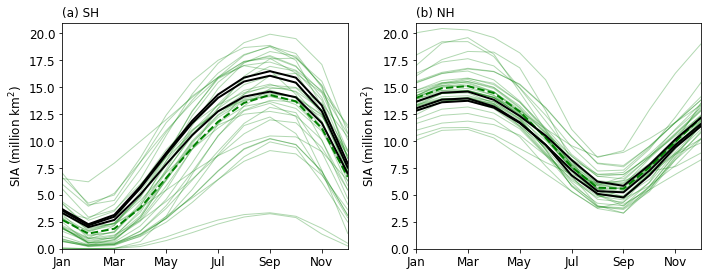

In [34]:
#mean over years (nanmean)
plt.rcParams.update({'font.size': 12})
model_ds = xr.open_dataset(mydir+'processed_CMIP6_sia_historical_r1.nc').sel(year=slice('1979','2014')).mean(dim='year')
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2014')).mean(dim='year')

# add manually
to_add = xr.open_dataset('../to_add_to_analysis/siarean_SImon_FGOALS-g3_historical_r1i1p1f1_gn_197901-201412_clim.nc').siarean
model_ds['sia_nh'].values[16,:] = to_add.values
to_add = xr.open_dataset('../to_add_to_analysis/siarean_SImon_CNRM-CM6-1-HR_historical_r1i1p1f2_gn_197901-201412_clim.nc').siarean
model_ds['sia_nh'].values[8,:] = to_add.values

fig = plt.figure(figsize=(10,4))
for h, hemi in enumerate(myhemi):   
    ax = plt.subplot(1,2,h+1)
    ax.set_xticks(np.arange(nm)[::2])
    ax.set_xticklabels(months[::2])
    ax.set_ylabel(r'SIA (million km$^2$)')
    ax.set_title(alph[h]+' '+hemi,loc='left',fontsize=12)
    ax.set_ylim([0.,21.])
    ax.set_xlim([0,nm-1])
    
    for model in model_ds.name.values:
        ax.plot(np.arange(nm),model_ds['sia_'+smallhemi[h]].sel(name=model),c='green',linewidth=1,alpha=.3)   
    ax.plot(np.arange(nm),model_ds['sia_'+smallhemi[h]].mean(dim='name'),c='green',linewidth=2,linestyle='--')
    for ob in obs_ds.name.values:
        ax.plot(np.arange(nm),obs_ds['sia_'+smallhemi[h]].sel(name=ob),c='black',linewidth=2)
    
    mmm = model_ds['sia_'+smallhemi[h]].mean(dim='name')
     
    if h == 0:
        lowestob = obs_ds['sia_'+smallhemi[h]].min(dim='name')
        for m in range(nm):
            print(months[m],(lowestob-mmm).values[m])
    print('----')
    if h ==1:
        highestob = obs_ds['sia_'+smallhemi[h]].max(dim='name')
        for m in range(nm):
            print(months[m],(mmm-highestob).values[m])
            
plt.tight_layout()
#fig.savefig('fig1',bbox_inches='tight',dpi=600)
plt.show(); plt.close()

In [20]:
check = model_ds.sia_sh.sel(month=2)
check = check.where(check>10.,drop=True)
check

<xarray.DataArray 'sia_sh' (name: 0)>
array([], dtype=float64)
Coordinates:
  * name     (name) object 
    month    int64 2

In [21]:
print(model_ds.sia_nh.argmin(dim='month').values) # 1 in Oct, 7 in Aug
print(model_ds.sia_nh.argmax(dim='month').values) # 1 in Apr, 2 in Feb
print(model_ds.sia_sh.argmin(dim='month').values)
print(model_ds.sia_sh.argmax(dim='month').values)

[7 8 8 7 7 7 8 8 8 8 8 7 8 7 7 8 7 7 7 8 8 7 7 7 8 8 8 7 8 8 8 8 8 7 8 8 7]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2]
[1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[8 8 8 8 8 8 8 8 9 9 9 8 8 8 8 8 7 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]


SH
NH


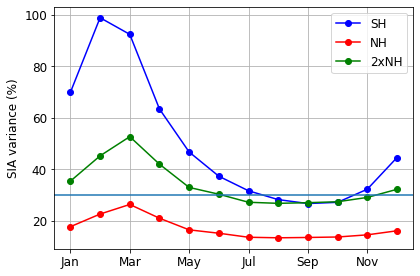

In [22]:
fig, ax = plt.subplots(1)   
ax.set_xticks(np.arange(nm)[::2])
ax.set_xticklabels(months[::2])
ax.set_ylabel(r'SIA variance (%)')
for h, hemi in enumerate(myhemi):    
  
    print(hemi)
    mydata = (100.*model_ds['sia_'+smallhemi[h]].std(dim='name')/model_ds['sia_'+smallhemi[h]].mean(dim='name')).values
    if h ==0:
        ax.plot(np.arange(nm), mydata ,label=hemi,c=gencolours[h],marker='o')
        
    elif h==1:
        ax.plot(np.arange(nm),np.append(mydata[6:],mydata[:6]) , label=hemi,c=gencolours[h],marker='o')
        ax.plot(np.arange(nm), 2.*np.append(mydata[6:],mydata[:6]), label='2x'+hemi,c='green',marker='o')
        
    
ax.axhline(y=30)
plt.grid()    
plt.legend()
plt.tight_layout()
plt.show(); plt.close()